In [ ]:
import matplotlib.pyplot as plt
import torch

from aef.data import HomographyData
from aef.data.blobboards import BlobBoardData

def visualize_homography_data(dataset: HomographyData, num_samples=4):
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, num_samples * 5))
    for i in range(num_samples):
        img, img_t, _, _ = dataset[i]
        axes[i, 0].imshow(img.permute(1, 2, 0).cpu())
        axes[i, 0].set_title("Original Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(img_t.permute(1, 2, 0).cpu())
        axes[i, 1].set_title("Transformed Image")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()

# data = HomographyData("../data/image-matching-challenge-2025/train/imc2024_dioscuri_baalshamin", image_size=(256, 256), in_memory=False, transform_params={"rotate": True, "scale": True})
data = BlobBoardData(4, image_size=(256, 256))
visualize_homography_data(data, num_samples=4)


In [ ]:
import kornia
import matplotlib.pyplot as plt
import torch

from aef.data import HomographyData
from aef.data.blobboards import BlobBoardData
from aef.models import NeuralScaleSpaceSESN

def visualize_scale_data(dataset: HomographyData, model, num_scales=4):
    fig, axes = plt.subplots(num_scales, 2, figsize=(10, num_scales * 5))
    scales = torch.linspace(0.1, 1, num_scales)
    
    for i in range(num_scales):
        img, _, _, _ = dataset[i]
        img_scaled = kornia.geometry.warp_perspective(img.unsqueeze(0), torch.diag(torch.tensor([scales[i], scales[i], 1], dtype=torch.float32)).unsqueeze(0), (img.size(1), img.size(2)))
        axes[i, 0].imshow(img_scaled.squeeze(0).permute(1, 2, 0).cpu())
        axes[i, 0].set_title("Original Image")
        axes[i, 0].axis("off")

        scale_field = model(img_scaled)
        print(torch.min(scale_field), torch.max(scale_field))

        axes[i, 1].imshow(scale_field.squeeze(0).permute(1, 2, 0).detach().cpu())
        axes[i, 1].set_title("Transformed Image")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()

model = NeuralScaleSpaceSESN(in_channels=1, num_scales=5)
model.load_state_dict(torch.load("../data/logs/scale_space_sesn_blobboards_rel_2026_04_23_15_40_57/checkpoints/epoch_0028.pth", map_location="cpu"))
model.eval()
# data = HomographyData("../data/image-matching-challenge-2025/train/imc2024_dioscuri_baalshamin", image_size=(256, 256), in_memory=False, transform_params={"rotate": True, "scale": True})
data = BlobBoardData(4, image_size=(256, 256))
visualize_scale_data(data, model, num_scales=4)
data = BlobBoardData(4, image_size=(256, 256))


In [1]:
%env TORCH_USE_CUDA_DSA=1
%env CUDA_LAUNCH_BLOCKING=1

env: TORCH_USE_CUDA_DSA=1
env: CUDA_LAUNCH_BLOCKING=1


Obtaining SIFT features [0/4]: 100%|██████████| 1/1 [00:00<00:00, 165.09it/s]


avg_keypoints_per_image=412.25


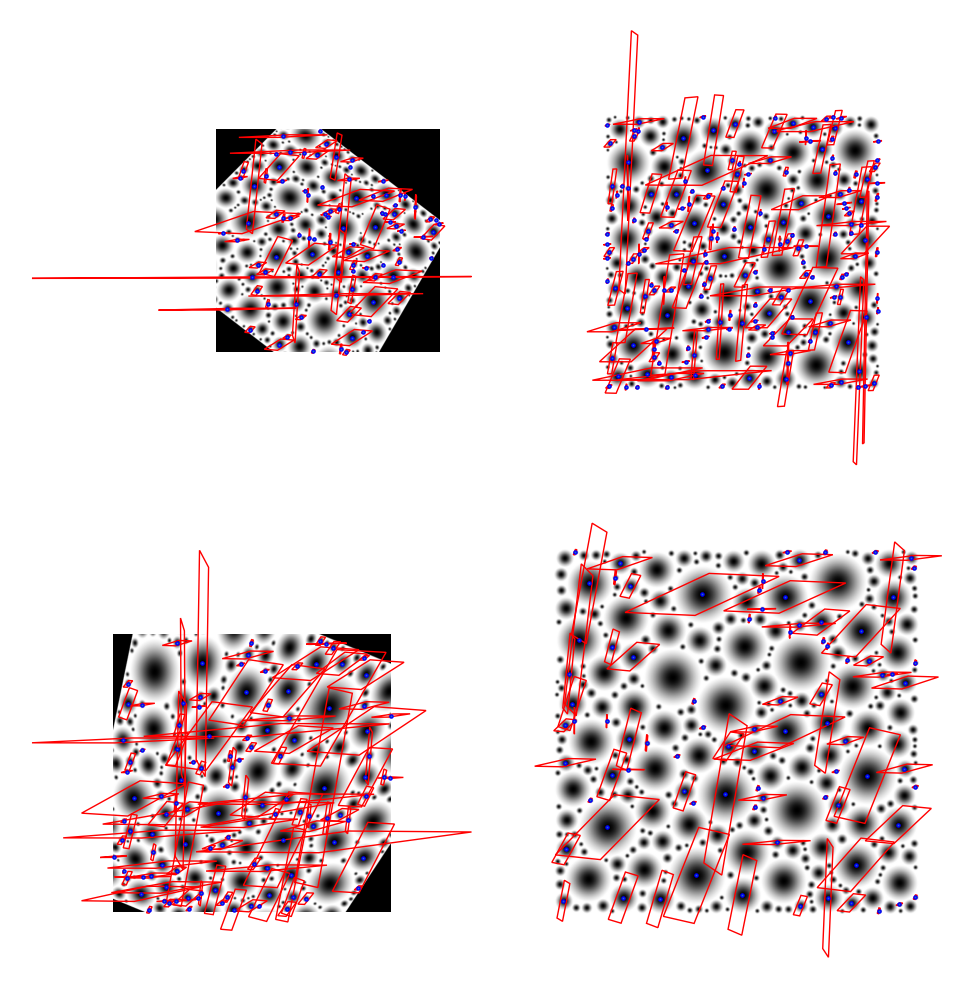

In [6]:
import matplotlib
from matplotlib import pyplot as plt
import torch
import numpy as np

from aef.data import KaggleHomographyData, HomographyData, BlobBoardHomographyData
from aef.models import AffineEquivariantUNet
from aef.train import homogenize


def visualize_detections(dataset: HomographyData, num_samples=4):
    fig, axes = plt.subplots(num_samples // 2, 2, figsize=(10, 10))
    dataloader = torch.utils.data.DataLoader(dataset, batch_size = 10000, collate_fn=dataset.get_collate_func())
    batch = next(iter(dataloader))
    img_ids = batch["keypoints"][..., 0].unique().tolist()
    for i in img_ids[:num_samples]:
        img = batch["images"][i].unsqueeze(0)
        coords = batch["keypoint_coords"][batch["keypoints"][..., 0] == i].cuda()
        coords_rounded = coords.round().int()
        coordinate_in_bound_mask = ((coords_rounded >= 0).all(dim=1) & (coords_rounded[:, 0] < img.size(3)) & (coords_rounded[:, 1] < img.size(2))).cpu()
        coords = coords[coordinate_in_bound_mask]
        coords_rounded = coords_rounded[coordinate_in_bound_mask]
        out = model(img.cuda()).permute(0, 3, 4, 1, 2)
        detections = out[:, coords_rounded[..., 1], coords_rounded[..., 0]]
        non_singular_mask = (torch.linalg.det(detections) > 1e-9).cpu()
        detections = detections[non_singular_mask]
        coords = coords[non_singular_mask.squeeze(0)]

        scale_correction = (((batch["scales"][batch["keypoints"][..., 0] == i][coordinate_in_bound_mask][non_singular_mask.squeeze()] * 2 * 2)).cuda() / torch.sqrt(torch.abs(torch.linalg.det(detections)))).unsqueeze(-1).unsqueeze(-1)
        detections = detections * scale_correction.view(-1, 1, 1)
        detections = homogenize(detections.squeeze(0), coords)
        # detections_t = homogenize(model(img_t.unsqueeze(0).cuda()).permute(0, 3, 4, 1, 2), b)

        # detections = detections[0, ::10, ::10].flatten(0, 1)
        # detections_t = detections_t[0, ::10, ::10].flatten(0, 1)

        detection_frames = (detections.unsqueeze(1) @ torch.Tensor([[-0.5, -0.5, 1], [0.5, -0.5, 1], [0.5, 0.5, 1], [-0.5, 0.5, 1]]).to(detections.device).unsqueeze(0).unsqueeze(-1)).squeeze()
        detection_frames = (detection_frames[..., :2] / detection_frames[..., 2:3]).detach().cpu().numpy()
        detection_frames = np.stack([detection_frames[..., 0], detection_frames[..., 1]], axis=-1)

        detection_patches = [matplotlib.patches.Polygon(detection_frames[i], closed=True, edgecolor="red", fill=False) for i in range(detection_frames.shape[0])]
        # blob_circle = [plt.Circle((coords[i, 0].cpu(), coords[i, 1].cpu()), radius=batch["scales"][batch["keypoints"][..., 0] == i][coordinate_in_bound_mask][non_singular_mask.squeeze()][i], color="blue", fill=False) for i in range(coords.size(0))]

        axes[i // 2, i % 2].imshow(img.squeeze(0).permute(1, 2, 0).cpu(), cmap="gray")
        for patch in detection_patches:
            axes[i // 2, i % 2].add_patch(patch)
        # for circ in blob_circle:
        #     axes[i // 2, i % 2].add_patch(circ)
        axes[i // 2, i % 2].scatter(coords[:, 0].cpu(), coords[:, 1].cpu(), s=5, edgecolor="blue")
        axes[i // 2, i % 2].axis("off")

        # axes[i, 1].imshow(img_t.permute(1, 2, 0).cpu())
        # axes[i, 1].set_title("Transformed Image")
        # axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()


model = AffineEquivariantUNet(in_channels=1)
model.load_state_dict(torch.load("/data/logs/2026_06_18_14_51_11_AffineEquivariantUNet_SiftScaleLoss_BlobLoss/checkpoints/best.pth", map_location="cpu")["model_state_dict"])

model.eval()
model = model.cuda()
data = BlobBoardHomographyData(num_boards=4, image_size=(512, 512))

visualize_detections(data, num_samples=4)

/workspace/affine-equivariant-features/src/aef/transforms/homography.py:169: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  flat_homography = np.linalg.lstsq(a_mat, p_mat)[0].T
Obtaining SIFT features [0/1]: 100%|██████████| 1/1 [00:00<00:00, 490.10it/s]


avg_keypoints_per_image=419.0
Pre-extracting multiscale patches into memory...


Warping Patches:   0%|          | 0/1 [00:00<?, ?it/s]

Warping Patches: 100%|██████████| 1/1 [00:01<00:00,  1.22s/it]


KeyError: 'images'

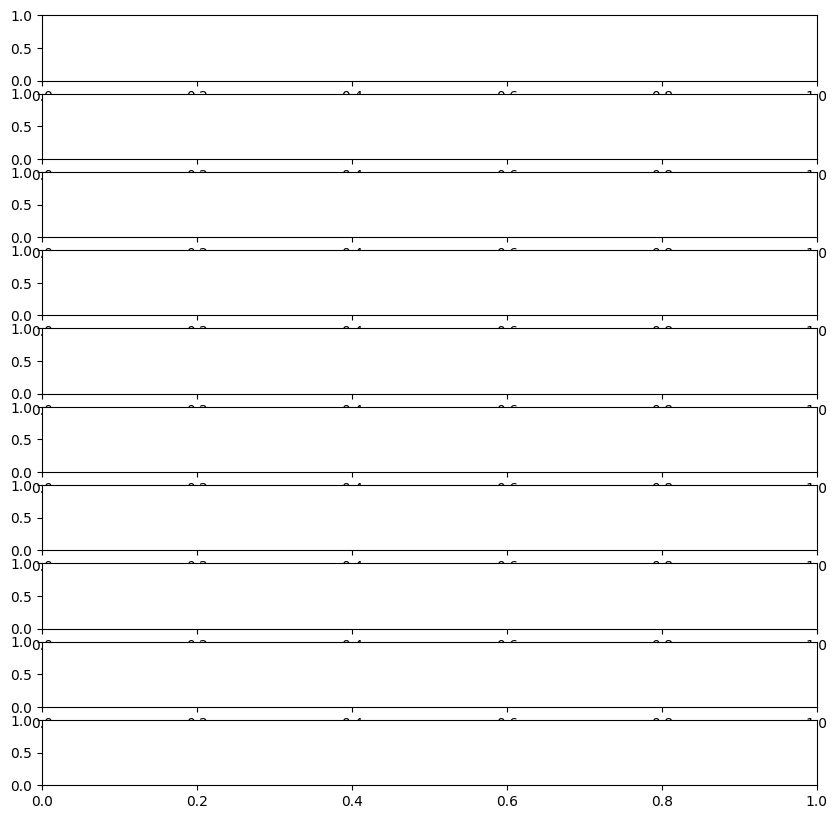

In [2]:
import kornia
import matplotlib
from matplotlib import pyplot as plt
import torch
import torchvision
import numpy as np

from aef.data import KaggleHomographyData, HomographyData, BlobBoardHomographyData
from aef.models import AffineEquivariantUNet
from aef.models.blob_descriptor import BlobDescriptorNoStride, BlobDescriptorRobust
from aef.train import homogenize, linearize_homography
from aef.train.canonicalizer import extract_patches
from aef.train.descriptor import sanity_check


def visualize_detections(dataset: HomographyData, num_samples=4):
    fig, axes = plt.subplots(10, figsize=(10, 10))
    dataloader = torch.utils.data.DataLoader(dataset, batch_size = 10000, collate_fn=dataset.get_collate_func())
    batch = next(iter(dataloader))

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = BlobDescriptorRobust().to(device)

    patch_size = 64
    img = batch["images"]
    keypoints = batch["keypoints"].to(device)
    keypoint_coords = batch["keypoint_coords"].to(device)
    scales = batch["scales"].to(device)

    _, *img_size = next(iter(img.values())).size()

    affine_shape = linearize_homography(batch["homographies"].to(device), coords=torch.cat((keypoint_coords, torch.ones(1, 1, device=device).expand(keypoint_coords.size(0), 1)), dim=-1))[..., :2, :2]
    coordinate_in_bound_mask = ((keypoint_coords >= 0).all(dim=1) & (keypoint_coords[:, 0] < img_size[1]) & (keypoint_coords[:, 1] < img_size[0])).cpu()
    keypoints = keypoints[coordinate_in_bound_mask]
    keypoint_coords = keypoint_coords[coordinate_in_bound_mask]
    scales = scales[coordinate_in_bound_mask]
    affine_shape = affine_shape[coordinate_in_bound_mask]
    patches = sanity_check(
        torch.stack([img[img_id.item()].to(device) for img_id in keypoints[..., 0]], dim=0),
        batch["homographies"][coordinate_in_bound_mask].to(device),
        keypoint_coords,
        scales,
        scale_factor=16
    ).to(device)

    out = model(patches)
    print( torch.cdist(out[:1], out[1:2], p=2.0))
    print( torch.cdist(out[1:2], out[2:3], p=2.0))
    print( torch.cdist(out[2:3], out[:1], p=2.0))


    rectangle_corners = torch.tensor([
        [-0.5, -0.5],
        [0.5, -0.5],
        [0.5, 0.5],
        [-0.5, 0.5],
    ], device=device, dtype=patches.dtype) * (patch_size)

    index_perm = torch.randperm(patches.size(0))

    for j in range(3):
        # index = index_perm[j] % 2
        # for col, patch_index in enumerate((index, index + 1)):
            axes[j].imshow(patches[j].permute(1, 2, 0).cpu(), cmap="gray")
            # rectangle = rectangle_corners @ affine_shape[patch_index].transpose(0, 1) + (patch_size / 2)
            # axes[j, col].add_patch(
            #     matplotlib.patches.Polygon(
            #         rectangle.detach().cpu().numpy(),
            #         closed=True,
            #         edgecolor="red",
            #         fill=False,
            #         linewidth=2,
            #     )
            # )

    plt.tight_layout()
    plt.show()

data = BlobBoardHomographyData(num_boards=1, image_size=(512, 512), in_memory=False)

visualize_detections(data, num_samples=4)